Setup

In [1]:
!pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Coding/RL clean copy`


  0.515135 seconds (2.22 M allocations: 124.282 MiB, 3.22% gc time, 99.43% compilation time)
  0.074793 seconds (913.21 k allocations: 99.144 MiB, 25.57% gc time, 36.08% compilation time)


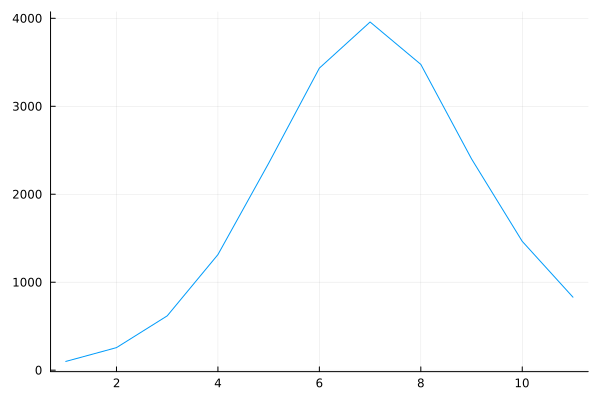

  2.837666 seconds (70.96 M allocations: 8.145 GiB, 9.92% gc time, 0.72% compilation time)


In [2]:
%pip install numpy
%pip install matplotlib
%pip install tensorboard
import numpy as np
import matplotlib.pyplot as plt
from juliacall import Main as jl
from juliacall import Pkg as jlPkg

jlPkg.activate(".")
jl.include("models/model_host_aware_adapt_scale.jl")
#jlPkg.instantiate() #run the first time using this repo

In [3]:
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding
from stable_baselines3 import PPO

# ==== Configuration ====
log_dir = "logs/rl_host"
model_path = os.path.join(log_dir, "ppo_model")

In [12]:
unc = np.random.rand(3)

In [13]:
jl.reward(0.6, unc)

6.2254659861496755

In [15]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding

# assume the Julia interface is already loaded as jl
# from juliacall import Main as jl

class CustomEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, max_episode_steps=5):
        super(CustomEnv, self).__init__()

        # ===== Environment dimensions =====
        self.obs_dim = 1           # observation = reward (scalar)
        self.action_dim = 1        # action = scalar in [-1, 1]
        self.uncertain_dim = 3     # hidden state (e.g., uncertain parameters)
        self.n_steps = max_episode_steps

        # ===== Spaces =====
        # same structure as before: (1, n_steps * (obs_dim + action_dim))
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(1, self.n_steps * (self.obs_dim + self.action_dim)),
            dtype=np.float32,
        )

        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.action_dim,),
            dtype=np.float32,
        )

        # ===== State variables =====
        self.max_episode_steps = max_episode_steps
        self.current_step = 0
        self.uncertain = np.zeros(self.uncertain_dim, dtype=np.float32)
        self.effective_observation = np.zeros(self.observation_space.shape, dtype=np.float32)

    # -------------------------------------
    #  Seeding
    # -------------------------------------
    def seed(self, seed=None):
        self._np_random, seed = seeding.np_random(seed)
        np.random.seed(seed)
        random.seed(seed)
        torch.manual_seed(seed)
        jl.seval(f"Random.seed!({seed})")  # sync seed with Julia
        return [seed]

    # -------------------------------------
    #  Reset
    # -------------------------------------
    def reset(self, seed=None, options=None):
        if options is not None and "uncertain" in options:
            self.uncertain = np.array(options["uncertain"], dtype=np.float32)
        else:
            self.uncertain = np.random.rand(self.uncertain_dim).astype(np.float32)
            # Sample from N(0.5, 0.5^2) truncated to [0, 1]
            # Note: this parameter is later rescaled by a factor of 2, making it
            # equivalent to sampling from N(1, 1^2) truncated to [0, 2].
            mu, sigma = 0.5, 0.5
            x = np.random.normal(mu, sigma)
            while x < 0.0 or x > 1.0:
                x = np.random.normal(mu, sigma)
            self.uncertain[1] = np.float32(x)

        if seed is not None:
            self.seed(seed)

        self.current_step = 0
        self.effective_observation[:] = 0.0

        info = {}
        return self.effective_observation.copy(), info

    # -------------------------------------
    #  Step
    # -------------------------------------
    def step(self, action):
        # ensure correct shape
        action = np.clip(action, -1, 1).astype(np.float32)
        action_scalar = float(action[0])

        obs_1 = torch.as_tensor(self.uncertain, dtype=torch.float32, device=model.device)
        obs_1 = obs_1.unsqueeze(0)  # add batch dimension [1, obs_dim]


        # compute reward (observation) from Julia
        reward = float(jl.reward(action_scalar, self.uncertain))
        noise_std = 0.1  # standard deviation of the noise
        obs_vector = np.array([[reward + np.random.normal(0, noise_std)]], dtype=np.float32)


        # fill in the effective observation buffer
        if self.current_step < self.max_episode_steps:
            obs_start = self.current_step * (self.obs_dim + self.action_dim)
            act_start = obs_start + self.obs_dim
            self.effective_observation[:, obs_start:act_start] = obs_vector
            self.effective_observation[:, act_start:act_start + self.action_dim] = action

        # increment
        self.current_step += 1
        terminated = self.current_step >= self.max_episode_steps
        truncated = False
        info = {}

        return self.effective_observation.copy(), reward, terminated, truncated, info


Training

In [75]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

os.makedirs(log_dir, exist_ok=True)

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})") 
env = CustomEnv()
env.seed(SEED)
env.reset(seed=SEED)
env = Monitor(env, filename=log_dir)

model = PPO(
    "MlpPolicy", 
    env,
    verbose=1,
    tensorboard_log=log_dir, 
    seed=SEED
)


Using cpu device
Wrapping the env in a DummyVecEnv.


In [17]:
# Train the model
model.learn(total_timesteps=1_000_000)
# runtime 51min 44s

# Save the model
model.save(os.path.join(log_dir, "ppo_model"))

Logging to logs/rl_host/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 4.43     |
| time/              |          |
|    fps             | 295      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 5           |
|    ep_rew_mean          | 5.16        |
| time/                   |             |
|    fps                  | 297         |
|    iterations           | 2           |
|    time_elapsed         | 13          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.021227287 |
|    clip_fraction        | 0.191       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.4        |
|    explained_variance   | -0.043      |


In [3]:
model.save(os.path.join(log_dir, "ppo_model"))

NameError: name 'model' is not defined

Evaluation

In [14]:
model.save(os.path.join(log_dir, "ppo_model"))

In [753]:
import os
import pandas as pd
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# test environment
env = CustomEnv()

log_dir = "logs/rl_host"
model_path = os.path.join(log_dir, "ppo_model")

model_path = os.path.join(log_dir, "ppo_model")
monitor_file = os.path.join(log_dir, "monitor.csv")

model = PPO.load(model_path)


df = pd.read_csv(monitor_file, skiprows=1)  # Skip header comment row

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


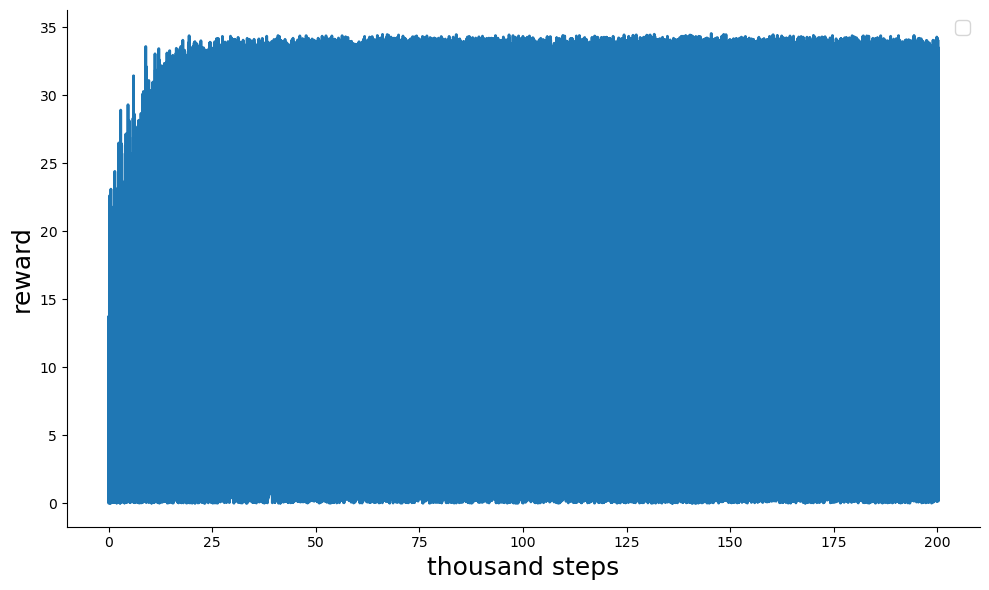

In [754]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))
sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_1.pdf", format="pdf")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


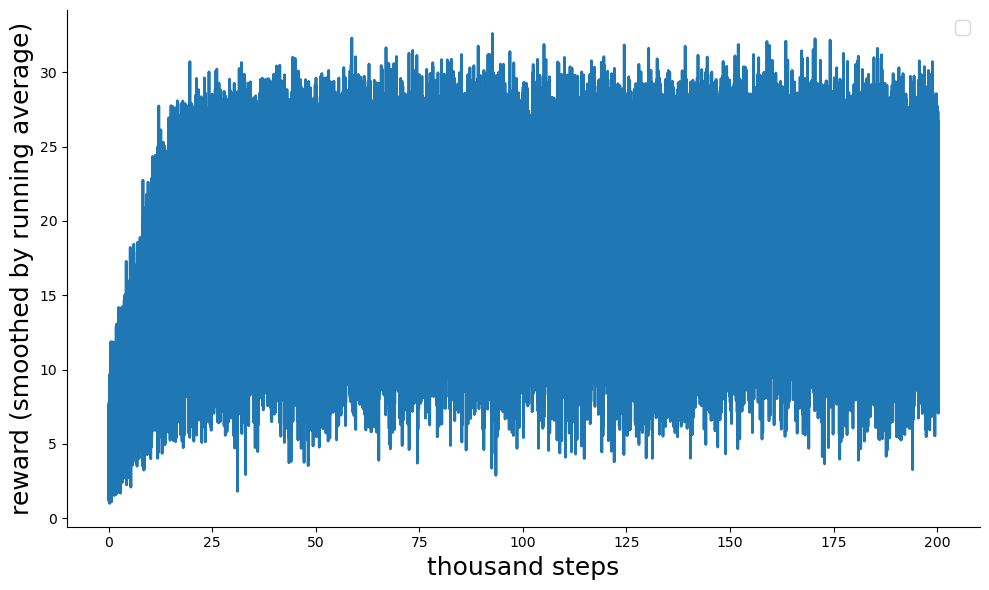

In [97]:
# ==== 3. Plot learning curve ====
plt.figure(figsize=(10, 6))

# Apply running average (rolling mean) with a window size of 5
df["r_smoothed"] = df["r"].rolling(window=5).mean()

sns.lineplot(x=[x / 1e3 for x in range(len(df))], y=df["r_smoothed"], linewidth=2)

plt.xlabel("thousand steps", fontsize=18)
plt.ylabel("reward (smoothed by running average)", fontsize=18)
plt.legend(fontsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("learning_curve_2.pdf", format="pdf")
plt.show()

In [98]:
# Store actions in a list
actions = []

# Generate 1000 samples
for _ in range(100000):
    # Reset env with random hidden_state (as in your example)
    obs, info = env.reset()
    
    # Predict action
    action, _states = model.predict(obs, deterministic=False)  # deterministic=False for stochastic sampling
    actions.append(action)

[0.61113816] 2.8814638
Reward at step 0: 2.705058520359589
[0.5162324] 1.7498308
Reward at step 1: 1.7098151367808299
[0.7404058] 3.7584345
Reward at step 2: 3.6605607262901483
[0.7822516] 3.893359
Reward at step 3: 3.6692696263814994
[0.7830633] 3.8543136
Reward at step 4: 3.6675578641489297


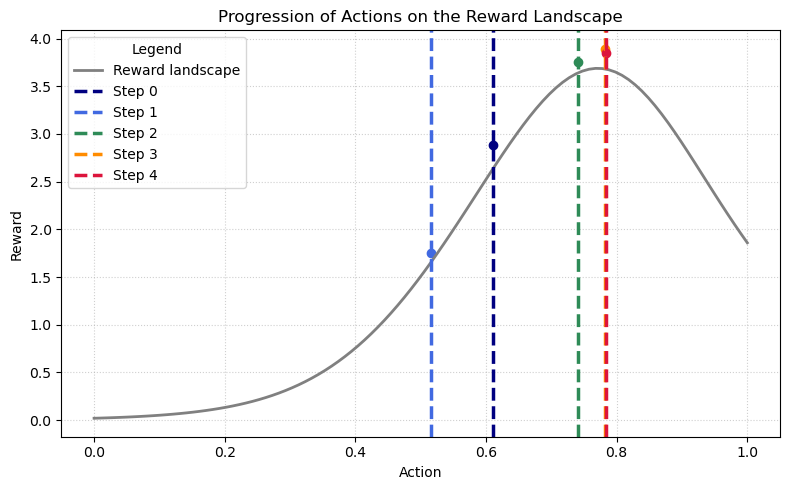

In [279]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(0)

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.reward(i/100, env.uncertain)

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(action,obs[0,2*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Progression of Actions on the Reward Landscape')
plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


[0.61113816] 0.87497956
Reward at step 0: 0.7125450411506745
[0.45732504] 0.12620617
Reward at step 1: 0.18738182010981938
[0.72620416] 1.5289049
Reward at step 2: 1.5817220389342839
[0.8641541] 2.9009583
Reward at step 3: 3.0082552657373403
[0.91277933] 3.5278378
Reward at step 4: 3.44129703517419


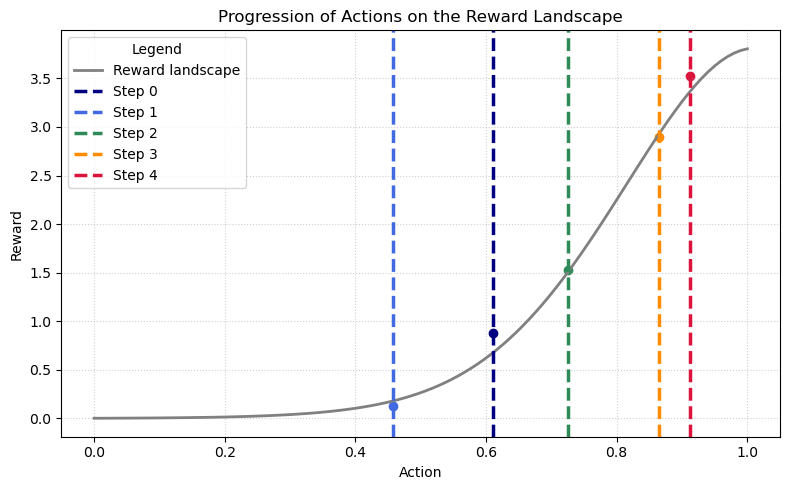

In [278]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(1)

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.reward(i/100, env.uncertain)

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(action,obs[0,2*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Progression of Actions on the Reward Landscape')
plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


[0.61113816] 0.44708017
Reward at step 0: 0.48875596162549023
[0.43762445] 0.5893209
Reward at step 1: 0.5949476097657396
[0.5088437] 0.4116564
Reward at step 2: 0.6252760164824336
[0.46855086] 0.78628784
Reward at step 3: 0.6222607585027229
[0.4639207] 0.4401454
Reward at step 4: 0.6194889488392811


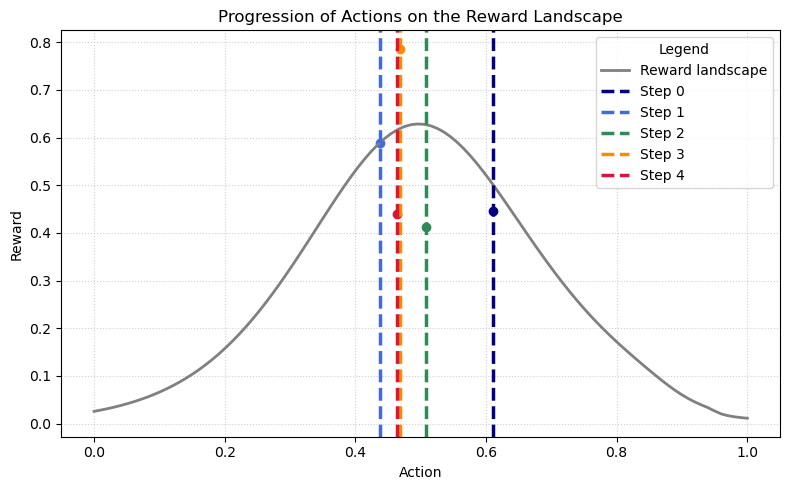

In [285]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(2)

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.reward(i/100, env.uncertain)

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(action,obs[0,2*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Progression of Actions on the Reward Landscape')
plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


[0.61113816] 2.2373173
Reward at step 0: 2.187468934221351
[0.50233907] 2.4345586
Reward at step 1: 2.4657104901111735
[0.516335] 2.5469332
Reward at step 2: 2.475810271680828
[0.5239548] 2.582584
Reward at step 3: 2.475317415681
[0.52715164] 2.31633
Reward at step 4: 2.473843089189582


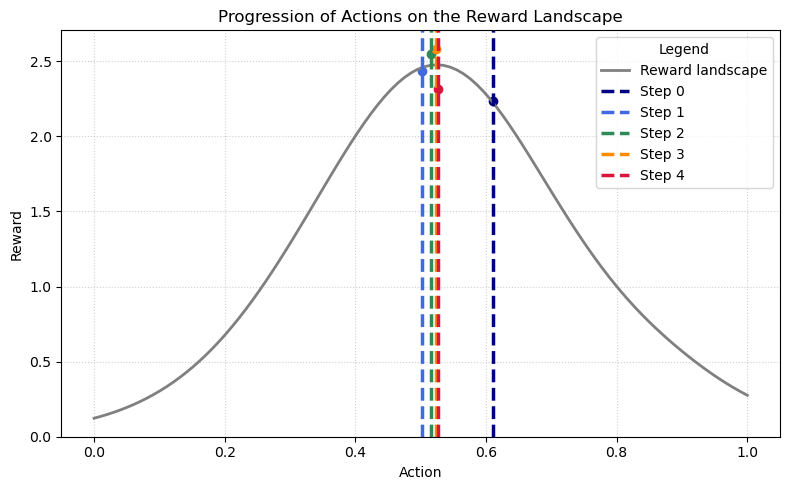

In [505]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset()

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.reward(i/100, env.uncertain)

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(action,obs[0,2*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Progression of Actions on the Reward Landscape')
plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


[0.61113816] 2.0084522
Reward at step 0: 1.9347169518555762
[0.49608332] 0.7945783
Reward at step 1: 0.8563080016490969
[0.74176836] 3.8387077
Reward at step 2: 3.7924145724106033
[0.91448367] 5.627043
Reward at step 3: 5.661461679581736
[0.9393155] 5.768246
Reward at step 4: 5.670289596269894


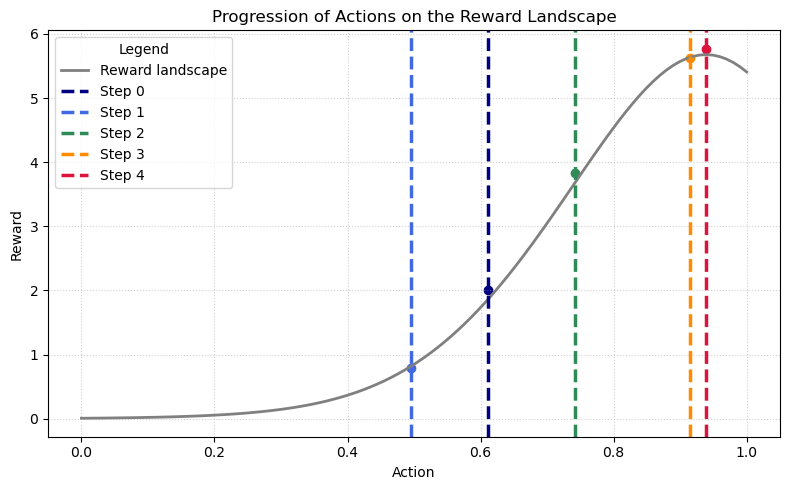

In [549]:
import numpy as np
import matplotlib.pyplot as plt

# Reset environment and get initial observation
obs, info = env.reset(1212)

# Compute reward landscape
vals = np.zeros(100)
for i in range(100):
    vals[i] = jl.reward(i/100, env.uncertain)

# Plot reward landscape
plt.figure(figsize=(8, 5))
plt.plot(np.linspace(0, 1, 100), vals, label='Reward landscape', color='gray', linewidth=2)

# Use dark, high-contrast colors with clear progression
colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']
n_steps = len(colors)

# Step loop
for step in range(n_steps):
    action, _states = model.predict(obs, deterministic=True)
    plt.axvline(x=action, color=colors[step], linestyle='--', linewidth=2.5, label=f'Step {step}')
    obs, reward, terminated, truncated, info = env.step(action)
    print(action,obs[0,2*step])
    plt.scatter(action,obs[0,2*step],color=colors[step])
    print(f"Reward at step {step}: {reward}")

# Labels and legend
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Progression of Actions on the Reward Landscape')
plt.legend(title='Legend', loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
# plt.show()


Initial random point: x0=0.417, y0=0.178


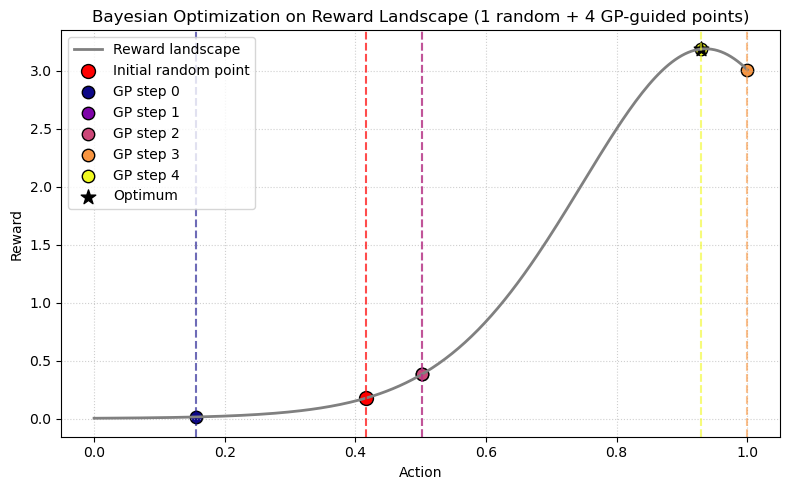

x=0.417, reward=0.178
x=0.156, reward=0.014
x=0.502, reward=0.382
x=0.502, reward=0.382
x=1.000, reward=3.008
x=0.929, reward=3.186


In [114]:
import numpy as np
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern


# --- Reward function wrapper ---
def reward_fn(x):
    # Ensure scalar conversion for Julia
    return float(jl.reward(float(x[0]), env.uncertain))

# --- Explicitly sample a random initial point ---
np.random.seed(1)
x0 = [np.random.uniform(0, 1)]           # 1 random initial action
y0 = [ -reward_fn([x0[0]]) ]             # corresponding negative reward (minimization)

print(f"Initial random point: x0={x0[0]:.3f}, y0={-y0[0]:.3f}")

# --- Run Bayesian Optimization with x0 and zero initial points ---
res = gp_minimize(
    func=lambda x: -reward_fn(x),          # minimize negative reward
    dimensions=[(0.0, 1.0)],               # action space
    n_calls=5,                             # total evaluations
    n_initial_points=0,                    # no random points generated internally
    x0=x0,
    y0=y0,
    random_state=42,
    base_estimator=GaussianProcessRegressor(kernel=Matern(nu=2.5))
)

# --- Compute reward landscape ---
x = np.linspace(0, 1, 200)
y = np.array(list(map(lambda xi: jl.reward(float(xi), env.uncertain), x)))

# --- Plotting ---
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='gray', lw=2, label='Reward landscape')

# Color palette for GP-guided points
colors = plt.cm.plasma(np.linspace(0, 1, len(res.x_iters)-1))

# --- Plot first random point ---
plt.scatter(x0[0], -y0[0], color='red', s=100, edgecolor='k', marker='o', label='Initial random point')
plt.axvline(x=x0[0], color='red', linestyle='--', alpha=0.7)

# --- Plot GP-guided points ---
for i, (xi, yi, c) in enumerate(zip(res.x_iters[1:], res.func_vals[1:], colors)):
    plt.scatter(xi, -yi, color=c, s=80, edgecolor='k', label=f'GP step {i}')
    plt.axvline(x=xi, color=c, linestyle='--', alpha=0.6)

# --- Highlight optimum found ---
plt.scatter(res.x[0], -res.fun, color='black', s=120, marker='*', label='Optimum')

# --- Styling ---
plt.xlabel('Action')
plt.ylabel('Reward')
plt.title('Bayesian Optimization on Reward Landscape (1 random + 4 GP-guided points)')
plt.legend(loc='best', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print final GP-guided points
for xi, yi in zip(res.x_iters, res.func_vals):
    print(f"x={xi[0]:.3f}, reward={-yi:.3f}")


In [61]:
first_rewards = np.zeros(1000)
second_rewards = np.zeros(1000)
third_rewards = np.zeros(1000)
forth_rewards = np.zeros(1000)
fifth_rewards = np.zeros(1000)

env.seed(31415)

for i in range(1000):
    obs, info = env.reset() 
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = reward
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = reward



Text(0, 0.5, 'Reward')

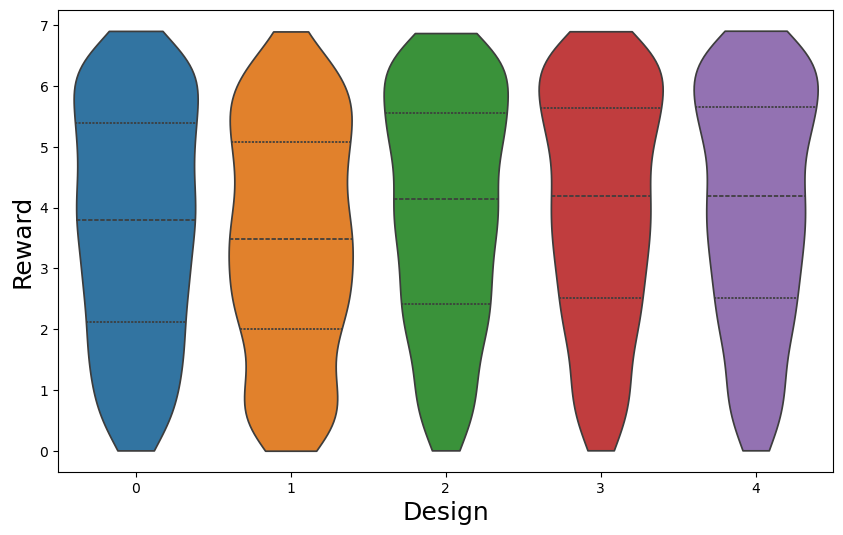

In [62]:
#plot violins seaborn
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards], inner="quartile", cut = 0)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)


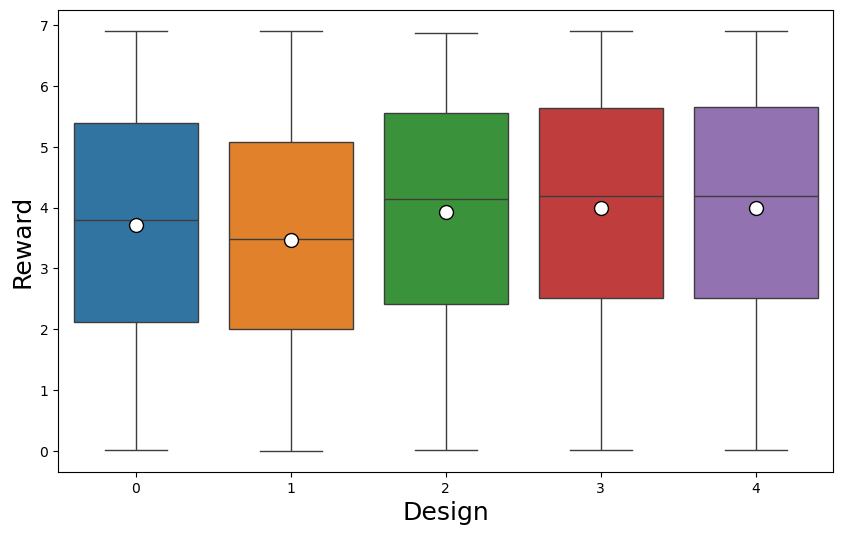

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,   # hides outliers
    showmeans=True,     # shows mean
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.show()


In [134]:
import numpy as np
from skopt import gp_minimize
from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import Matern

# Storage for environment rewards (regrets)
first_rewards = np.zeros(100)
second_rewards = np.zeros(100)
third_rewards = np.zeros(100)
forth_rewards = np.zeros(100)
fifth_rewards = np.zeros(100)

env.seed(31415)

# Run 100 independent BO trials
for i in range(100):
    obs, info = env.reset()

    # --- Define BO objective ---
    # For each candidate action, we take a real environment step
    # and return the *negative* observable used by BO.
    def reward_fn(x):
        # Take one environment step with this action
        obs_next, reward, terminated, truncated, info = env.step([x[0]])
        # Store actual reward in the correct slot
        step_idx = len(actions_so_far)
        if step_idx == 0:
            first_rewards[i] = reward
        elif step_idx == 1:
            second_rewards[i] = reward
        elif step_idx == 2:
            third_rewards[i] = reward
        elif step_idx == 3:
            forth_rewards[i] = reward
        elif step_idx == 4:
            fifth_rewards[i] = reward
        # Return the *proxy* observable (obs_next[0, 2*step]) for BO
        # but as a negative value since gp_minimize minimizes
        return -float(obs_next[0, 2 * step_idx])

    # --- Keep track of how many steps have been taken ---
    actions_so_far = []

    # --- Random initial point ---
    x0 = [np.random.uniform(0, 1)]
    actions_so_far.append(x0[0])

    # Evaluate initial point (this calls env.step)
    y0 = [reward_fn([x0[0]])]

    # --- Bayesian optimization using that starting point ---
    res = gp_minimize(
        func=reward_fn,
        dimensions=[(0.0, 1.0)],
        n_calls=5,                # total evaluations (1 random + 4 BO-guided)
        n_initial_points=0,       # we already supplied x0, y0
        x0=x0,
        y0=y0,
        random_state=42 + i,
        base_estimator=GaussianProcessRegressor(kernel=Matern(nu=2.5))
    )

# Done: first_rewards, second_rewards, ... now hold 100×5 actual environment rewards


In [82]:
import torch
import torch.nn as nn
import torch.optim as optim

class RewardRegressor(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

In [83]:
# Recreate the model and optimizer
regressor = RewardRegressor()
optimizer = optim.Adam(regressor.parameters(), lr=1e-3)

# Load the saved checkpoint
checkpoint = torch.load('reward_regressor.pth')
regressor.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
loss = checkpoint['loss']

# Set the model to evaluation mode if using it for inference
regressor.eval()


/var/folders/g5/zfzq1xm948s47p2wdqk_5ql00000gn/T/ipykernel_81735/3946597296.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('reward_regressor.pth

RewardRegressor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [84]:
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
import random
from gymnasium.utils import seeding
from stable_baselines3 import PPO

# ==== Configuration ====
log_dir = "logs/rl_host_multi_fully_obs_2"
model_path = os.path.join(log_dir, "ppo_model")

model_fully_obs = PPO.load(model_path)

In [115]:
unc_tens = torch.as_tensor(env.uncertain, dtype=torch.float32, device=model.device)
unc_tens = unc_tens.unsqueeze(0)  # add batch dimension [1, obs_dim]       
with torch.no_grad():
            y_pred = regressor(unc_tens).squeeze().numpy()
with torch.no_grad():
            value = model_fully_obs.policy.predict_values(unc_tens).item()*4 * y_pred
print(value)

if not abs(value)<0.01:
    reward = (reward - value)/abs(value)
else:
    reward = (reward - value)

2.999119332199797


In [383]:
np.argmin(fifth_rewards)

800

In [743]:
first_rewards = np.zeros(100)
second_rewards = np.zeros(100)
third_rewards = np.zeros(100)
forth_rewards = np.zeros(100)
fifth_rewards = np.zeros(100)

env.seed(0)

for i in range(100):

# Compute reward landscape
    obs, info = env.reset() 
    vals = np.zeros(100)
    for j in range(100):
        vals[j] = jl.reward(j/100, env.uncertain)
    value = 1* np.max(vals)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    first_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    second_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    third_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    forth_rewards[i] = (reward - value)
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    fifth_rewards[i] = (reward - value)



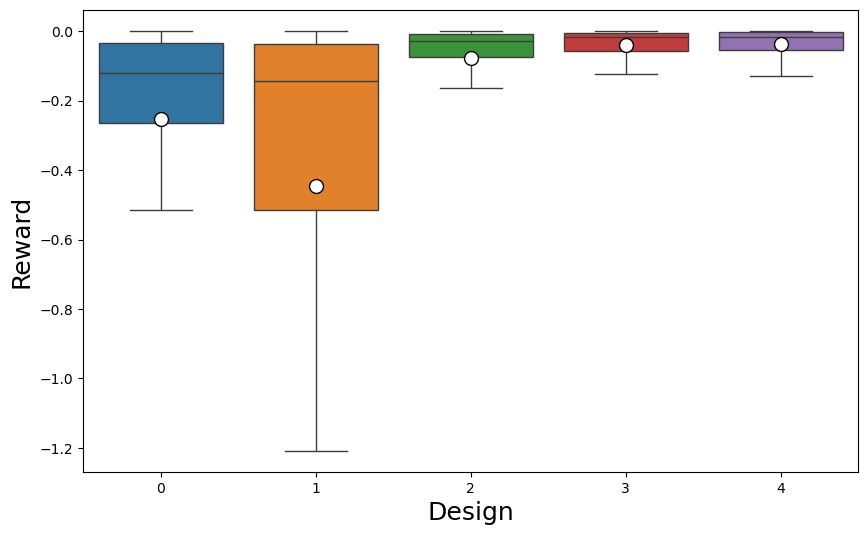

In [735]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    showfliers=False,   # hides outliers
    showmeans=True,     # shows mean
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":10}
)
plt.xlabel("Design", fontsize=18)
plt.ylabel("Reward", fontsize=18)
plt.show()


/var/folders/g5/zfzq1xm948s47p2wdqk_5ql00000gn/T/ipykernel_81735/3824309447.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 6))


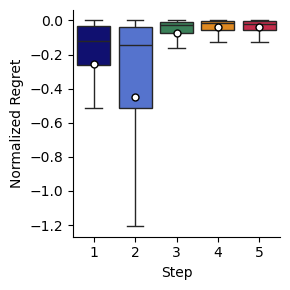

In [744]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(3, 3))
ax = sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    palette=colors,
    showfliers=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    },
)

plt.xlabel("Step")
plt.ylabel("Normalized Regret")
ax.set_xticklabels(range(1, 6))
sns.despine()

plt.tight_layout()
plt.savefig("boxplot.pdf", bbox_inches="tight")
plt.show()


/var/folders/g5/zfzq1xm948s47p2wdqk_5ql00000gn/T/ipykernel_81735/4200708236.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(range(1, 6))


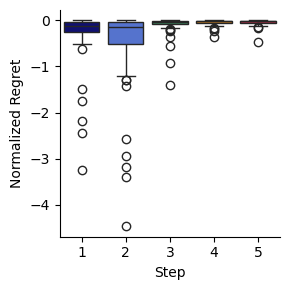

In [742]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = ['navy', 'royalblue', 'seagreen', 'darkorange', 'crimson']

plt.figure(figsize=(3, 3))
ax = sns.boxplot(
    data=[first_rewards, second_rewards, third_rewards, forth_rewards, fifth_rewards],
    palette=colors,
    showfliers=True,
)

plt.xlabel("Step")
plt.ylabel("Normalized Regret")
ax.set_xticklabels(range(1, 6))
sns.despine()

plt.tight_layout()
plt.savefig("boxplot_2.pdf", bbox_inches="tight")
plt.show()


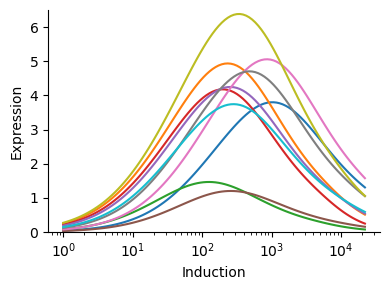

In [758]:
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")  # your Julia seed
env.seed(SEED)
env.reset(seed=SEED)

import matplotlib.pyplot as plt
import numpy as np
import torch

# Number of samples along action dimension
n_points = 100
x = np.linspace(0, 1, n_points)

x_log = np.linspace(0, 10, n_points)

x_axis = np.exp(x_log)  # shape (n_points, 1)

# Number of different uncertain parameters to visualize
n_curves = 10

plt.figure(figsize=(4, 3))

for _ in range(n_curves):
    env.reset()
    vals = np.array([jl.reward(a, env.uncertain) for a in x])
    plt.plot(x_axis, vals, label=f'unc={unc.round(2)}')

plt.xlabel('Induction')
plt.xscale('log')
plt.ylabel('Expression')
plt.ylim(0, 6.5)
sns.despine()
plt.tight_layout()
plt.savefig("curves.pdf", format="pdf")
plt.show()



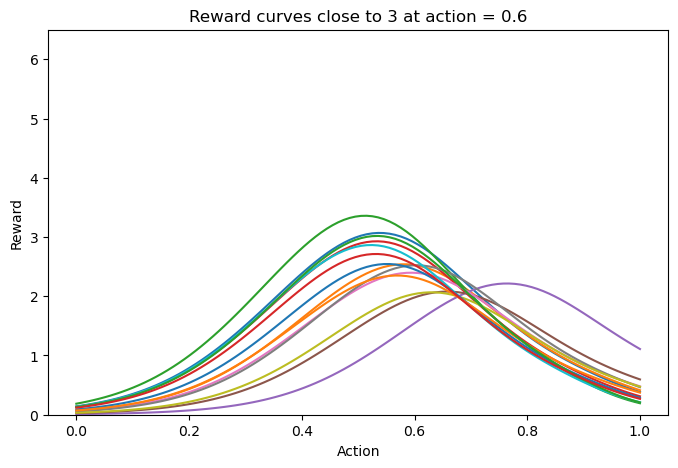

In [761]:
SEED = 2

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
jl.seval(f"Random.seed!({SEED})")
env.seed(SEED)
env.reset(seed=SEED)

import matplotlib.pyplot as plt
import numpy as np
import torch

n_points = 100
x = np.linspace(0, 1, n_points)

n_curves = 300
target_action = 0.7
target_value = 2.0
tol = 0.2  # closeness threshold

plt.figure(figsize=(8, 5))

for _ in range(n_curves):
    env.reset()
    unc = env.uncertain
    vals = np.array([jl.reward(a, unc) for a in x])

    # --- filter condition ---
    reward_at_target = jl.reward(target_action, unc)
    if abs(reward_at_target - target_value) > tol:
        continue  # skip this curve


    plt.plot(x, vals, label=f'unc={unc.round(2)}')


plt.xlabel('Action')
plt.ylabel('Reward')
plt.ylim(0, 6.5)
plt.savefig("selected_curves.pdf", format="pdf")
plt.title('Reward curves close to 3 at action = 0.6')
plt.show()
